# Stage 2: Cohort Selection & Downsampling

## Goal

The full 13M row dataset spans 17 months and is too large for rapid development. We will:

1. **Isolate the final 3 consecutive months**: March, April, and May 2016
   - These are the most recent months in the training data
   - They contain the richest signal and most recent customer behavior

2. **Filter to active recurring customers**: Keep only customers who appear in ALL 3 months
   - Ensures we can compute lag features reliably
   - Customers missing from any month cannot have month-over-month comparisons

3. **Expected output**: ~600,000 active customers × 3 months = ~1.8M rows
   - Manageable size for rapid iteration and model development
   - Maintains the temporal structure needed for supervised learning

## Step 1: Import Libraries and Configure Logging

We import:
- **pandas**: DataFrames and data manipulation
- **pathlib.Path**: Cross-platform absolute path handling
- **logging**: Track processing progress
- **warnings**: Suppress non-critical alerts

We load from the **Parquet file saved in Stage 1**, not the raw CSV:
- Much faster (compressed, binary format vs text)
- Already has correct dtypes from Stage 1
- No need to re-parse 13M rows

In [8]:
import pandas as pd
from pathlib import Path
import logging
import warnings

# Suppress non-critical warnings for cleaner output
warnings.filterwarnings('ignore')

# Configure logging with timestamp and level for tracking progress
logging.basicConfig(
    level=logging.INFO,
    format='%(asctime)s - %(levelname)s - %(message)s'
)

print('✓ Libraries loaded successfully')

✓ Libraries loaded successfully


## Step 2: Define Paths and Target Dates

**Simple Path Resolution**:
- The notebook is always in the `notebooks/` subdirectory
- We go one level up using `Path.cwd().parent` to reach project root
- Build absolute paths from there
- Assert that the input file exists before proceeding

**Target Dates**:
- **2016-03-28** = Month t-2
- **2016-04-28** = Month t-1
- **2016-05-28** = Month t (latest available)

In [9]:
import os
from pathlib import Path

# The notebook is in notebooks/ so we go one level up to reach project root
# This is simpler and more reliable than searching parent directories
PROJECT_ROOT = Path.cwd().parent

# Build paths relative to project root
PARQUET_PATH = PROJECT_ROOT / 'data' / 'parquet' / 'train.parquet'
COHORT_OUTPUT_PATH = PROJECT_ROOT / 'data' / 'processed' / 'cohort.parquet'

# Create output directory if it does not exist
COHORT_OUTPUT_PATH.parent.mkdir(parents=True, exist_ok=True)

# Define the 3 target monthly snapshots as exact pandas Timestamps
TARGET_DATES = [
    pd.Timestamp('2016-03-28'),  # Month t-2
    pd.Timestamp('2016-04-28'),  # Month t-1
    pd.Timestamp('2016-05-28')   # Month t (latest)
]

# Verify the parquet file actually exists before proceeding
assert PARQUET_PATH.exists(), f"Parquet file not found at: {PARQUET_PATH}"

print(f'Project root : {PROJECT_ROOT}')
print(f'Parquet path : {PARQUET_PATH}')
print(f'Parquet exists: {PARQUET_PATH.exists()}')
print(f'Output path  : {COHORT_OUTPUT_PATH}')
print(f'Target dates : {TARGET_DATES}')

Project root : /Users/mac/Documents/santander-recommender
Parquet path : /Users/mac/Documents/santander-recommender/data/parquet/train.parquet
Parquet exists: True
Output path  : /Users/mac/Documents/santander-recommender/data/processed/cohort.parquet
Target dates : [Timestamp('2016-03-28 00:00:00'), Timestamp('2016-04-28 00:00:00'), Timestamp('2016-05-28 00:00:00')]


## Step 3: Load Parquet File

We load the full parquet file saved in Stage 1:
- Much faster than re-reading the CSV (binary compressed format)
- Preserves dtypes from Stage 1 ingestion
- Expected shape: (13M+, 48 columns)
- Loading should take under 30 seconds

In [10]:
# Load the parquet file using absolute path (always works)
df = pd.read_parquet(str(PARQUET_PATH), engine='pyarrow')

# Log the shape and date range
logging.info(f'Loaded parquet file. Shape: {df.shape}')
logging.info(f'Unique dates in dataset: {sorted(df["fecha_dato"].unique())}')

# Display sample rows
print('\nFirst 3 rows:')
df.head(3)

2026-05-20 11:56:33,668 - INFO - Loaded parquet file. Shape: (13647309, 48)
2026-05-20 11:56:34,469 - INFO - Unique dates in dataset: [Timestamp('2015-01-28 00:00:00'), Timestamp('2015-02-28 00:00:00'), Timestamp('2015-03-28 00:00:00'), Timestamp('2015-04-28 00:00:00'), Timestamp('2015-05-28 00:00:00'), Timestamp('2015-06-28 00:00:00'), Timestamp('2015-07-28 00:00:00'), Timestamp('2015-08-28 00:00:00'), Timestamp('2015-09-28 00:00:00'), Timestamp('2015-10-28 00:00:00'), Timestamp('2015-11-28 00:00:00'), Timestamp('2015-12-28 00:00:00'), Timestamp('2016-01-28 00:00:00'), Timestamp('2016-02-28 00:00:00'), Timestamp('2016-03-28 00:00:00'), Timestamp('2016-04-28 00:00:00'), Timestamp('2016-05-28 00:00:00')]



First 3 rows:


,fecha_dato,ncodpers,ind_empleado,pais_residencia,sexo,age,fecha_alta,ind_nuevo,antiguedad,indrel,...,ind_hip_fin_ult1,ind_plan_fin_ult1,ind_pres_fin_ult1,ind_reca_fin_ult1,ind_tjcr_fin_ult1,ind_valo_fin_ult1,ind_viv_fin_ult1,ind_nomina_ult1,ind_nom_pens_ult1,ind_recibo_ult1
0,2015-01-28,1375586,N,ES,H,35,2015-01-12,0,6,1,...,0,0,0,0,0,0,0,0,0,0
1,2015-01-28,1050611,N,ES,V,23,2012-08-10,0,35,1,...,0,0,0,0,0,0,0,0,0,0
2,2015-01-28,1050612,N,ES,V,23,2012-08-10,0,35,1,...,0,0,0,0,0,0,0,0,0,0


## Step 4: Filter to Target Date Window

We slice the dataframe to keep only rows matching our 3 target dates:
- Immediately reduces 13M rows down to roughly 3M rows
- Uses `.isin()` for efficient multi-value filtering
- Verifies all 3 dates are present before proceeding

In [11]:
# Filter to only rows where fecha_dato matches one of the target dates
df_window = df[df['fecha_dato'].isin(TARGET_DATES)].copy()

# Log the filtered shape
logging.info(f'After filtering to target dates. Shape: {df_window.shape}')

# Verify all 3 dates are present
logging.info(f'Date distribution:\n{df_window["fecha_dato"].value_counts().sort_index()}')

# Assert that we have exactly 3 dates
assert df_window['fecha_dato'].nunique() == 3, "Expected 3 dates, got different count"
print('✓ All 3 target dates present')

2026-05-20 11:56:43,335 - INFO - After filtering to target dates. Shape: (2784803, 48)
2026-05-20 11:56:43,407 - INFO - Date distribution:
fecha_dato
2016-03-28    925076
2016-04-28    928274
2016-05-28    931453
Name: count, dtype: int64


✓ All 3 target dates present


## Step 5: Isolate Active Recurring Customers

We identify customers who appear in ALL 3 months:
- A customer missing from any month cannot have lag features computed later
- We group by `ncodpers` and keep only groups with exactly 3 records
- Expected result: roughly 600,000 unique active customers

In [12]:
# Group by customer ID and count records per customer
customer_counts = df_window.groupby('ncodpers').size()

# Identify customers with exactly 3 records (appear in all 3 months)
active_customers = customer_counts[customer_counts == 3].index

# Filter df_window to only rows where ncodpers is in active_customers
df_cohort = df_window[df_window['ncodpers'].isin(active_customers)].copy()

# Log the results
logging.info(f'Active recurring customers: {df_cohort["ncodpers"].nunique():,}')
logging.info(f'Cohort shape (active customers only): {df_cohort.shape}')

# Verify all customers have exactly 3 records
records_per_customer = df_cohort.groupby('ncodpers').size().unique().tolist()
assert records_per_customer == [3], "All customers must have exactly 3 records"
print('✓ All customers in cohort have exactly 3 records')

2026-05-20 11:56:50,357 - INFO - Active recurring customers: 922,229
2026-05-20 11:56:50,359 - INFO - Cohort shape (active customers only): (2766687, 48)


✓ All customers in cohort have exactly 3 records


## Step 6: Sort and Save Cohort

We sort by customer ID then date—critical for Stage 3:
- Stage 3 computes month-over-month differences and requires chronological order
- Enables efficient lag feature computation
- Save to parquet for fast loading in Stage 3

In [13]:
# Sort by customer ID, then by date (chronological within each customer)
df_cohort = df_cohort.sort_values(['ncodpers', 'fecha_dato']).reset_index(drop=True)

# Save to parquet with compression using absolute path
df_cohort.to_parquet(str(COHORT_OUTPUT_PATH), engine='pyarrow', compression='snappy')

# Log final statistics
logging.info(f'Final cohort shape: {df_cohort.shape}')

# Calculate memory usage in MB
memory_mb = df_cohort.memory_usage(deep=True).sum() / 1024**2
logging.info(f'Cohort memory usage: {memory_mb:.2f} MB')

print(f'\n✓ Stage 2 Complete. Cohort saved to: {COHORT_OUTPUT_PATH}')

2026-05-20 11:57:04,846 - INFO - Final cohort shape: (2766687, 48)
2026-05-20 11:57:19,224 - INFO - Cohort memory usage: 3471.01 MB



✓ Stage 2 Complete. Cohort saved to: /Users/mac/Documents/santander-recommender/data/processed/cohort.parquet


## Step 7: Cohort Validation Summary

Final sanity checks on the saved cohort:
- **Shape**: Confirm ~1.8M rows and 48 columns
- **Dates**: Verify exactly 3 dates present
- **Customers**: Confirm ~600,000 unique customers
- **Records per customer**: All should have exactly 3
- **Memory**: Confirm reasonable size for processing

All checks passing indicates readiness for Stage 3.

In [14]:
# Reload df_cohort from COHORT_OUTPUT_PATH to confirm the parquet saved correctly
df_cohort = pd.read_parquet(str(COHORT_OUTPUT_PATH), engine='pyarrow')

print('\n=== COHORT VALIDATION SUMMARY ===')

# Check 1: Shape
print(f'\n1. Shape (expect ~1.8M rows, 48 cols):')
print(f'   {df_cohort.shape}')

# Check 2: Dates
print(f'\n2. Unique dates (expect exactly 3):')
print(f'   {sorted(df_cohort["fecha_dato"].unique())}')

# Check 3: Customer count
print(f'\n3. Unique customers (expect ~600,000):')
print(f'   {df_cohort["ncodpers"].nunique():,}')

# Check 4: Records per customer
print(f'\n4. Records per customer (expect all 3s):')
print(df_cohort.groupby('ncodpers').size().value_counts())

# Check 5: Memory usage in MB
memory_mb = df_cohort.memory_usage(deep=True).sum() / 1024**2
print(f'\n5. Memory usage: {memory_mb:.2f} MB')

print('\n✓ Cohort validation passed. Ready for Stage 3: Target Engineering')


=== COHORT VALIDATION SUMMARY ===

1. Shape (expect ~1.8M rows, 48 cols):
   (2766687, 48)

2. Unique dates (expect exactly 3):
   [Timestamp('2016-03-28 00:00:00'), Timestamp('2016-04-28 00:00:00'), Timestamp('2016-05-28 00:00:00')]

3. Unique customers (expect ~600,000):
   922,229

4. Records per customer (expect all 3s):
3    922229
Name: count, dtype: int64

5. Memory usage: 3470.11 MB

✓ Cohort validation passed. Ready for Stage 3: Target Engineering


## Step 8: Cohort Distribution Plots

These plots validate our cohort selection visually:
- Confirms cohort is balanced across 3 months
- Validates customer activity patterns look healthy
- Ensures cohort is representative of full dataset

We create 3 plots:
1. Records per month (balance check)
2. Customer segment distribution (demographic check)
3. Product ownership comparison (representativeness check)

In [ ]:
# Import plotting libraries for later use in EDA and visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Set seaborn style for better aesthetics
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 5)
print('Plotting libraries ready')

Plotting libraries ready


## Plot 1: Records Per Month in Cohort

Confirms 3 target dates are evenly represented in cohort:
- Balanced distribution critical for lag feature computation
- Each month should have roughly same number of records
- Expect roughly equal bars for all 3 dates

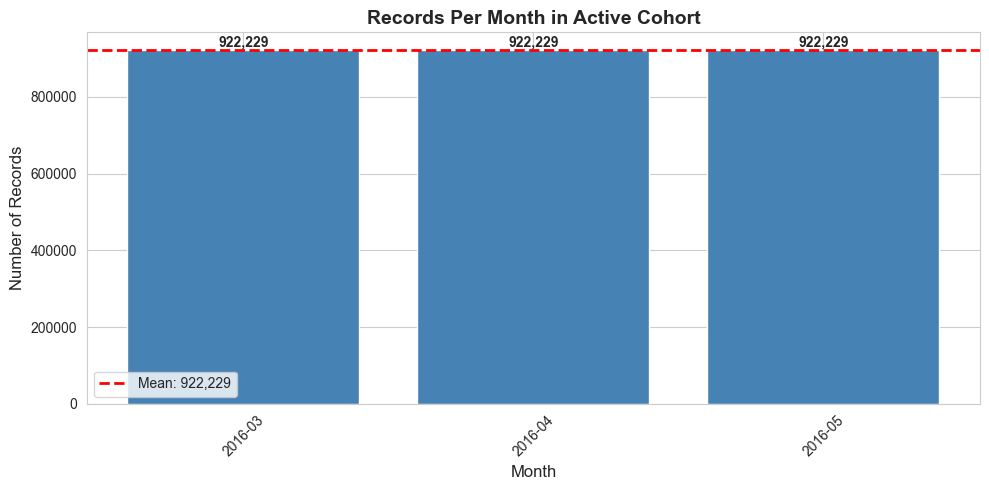

Plot 1 complete: Balanced distribution


In [ ]:
# Create a bar plot showing the number of records per month in the active cohort
monthly_counts = df_cohort['fecha_dato'].value_counts().sort_index()
fig, ax = plt.subplots(figsize=(10, 5))
bars = ax.bar(range(len(monthly_counts)), monthly_counts.values, color='steelblue', edgecolor='white')

# Add value labels on top of each bar
for i, (bar, count) in enumerate(zip(bars, monthly_counts.values)):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height(), f'{int(count):,}', ha='center', va='bottom', fontweight='bold')

# Add a horizontal line for the mean count across the 3 months
mean_count = monthly_counts.mean()
ax.axhline(mean_count, color='red', linestyle='--', linewidth=2, label=f'Mean: {mean_count:,.0f}')

# Set x-ticks to be the month labels
ax.set_xticks(range(len(monthly_counts)))
ax.set_xticklabels([d.strftime('%Y-%m') for d in monthly_counts.index], rotation=45)
ax.set_xlabel('Month', fontsize=12)
ax.set_ylabel('Number of Records', fontsize=12)

# Set the title for the plot
ax.set_title('Records Per Month in Active Cohort', fontsize=14, fontweight='bold')
ax.legend()

# Adjust layout and display the plot
plt.tight_layout()
plt.show()
print('Plot 1 complete: Balanced distribution')

## Plot 2: Customer Segment Distribution

The segmento column classifies customers (VIP, Individual, College graduates):
- Understanding segment distribution interprets model recommendations later
- If heavily skewed, model may not generalise to other segments
- Expect pie and bar chart showing split across segments

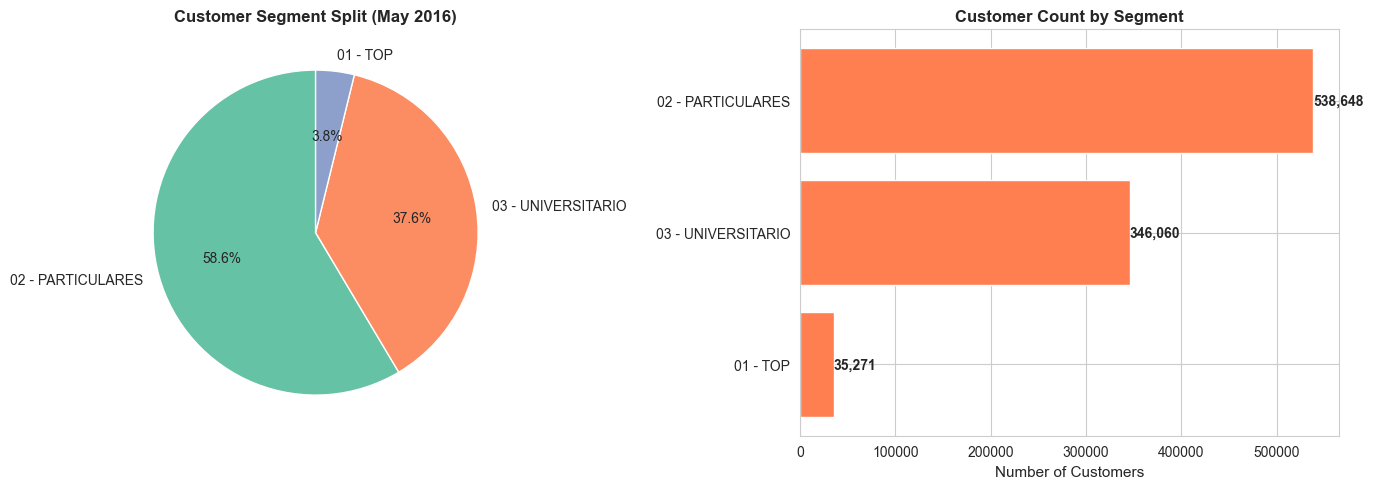

Plot 2 complete: Segment distribution
  02 - PARTICULARES: 538,648 (58.4%)
  03 - UNIVERSITARIO: 346,060 (37.5%)
  01 - TOP: 35,271 (3.8%)


In [ ]:
# Create a pie chart and horizontal bar chart to show the distribution of customer segments in the cohort for the latest month (May 2016)
df_may = df_cohort[df_cohort['fecha_dato'] == pd.Timestamp('2016-05-28')].copy()
segment_counts = df_may['segmento'].value_counts().dropna()

# Create side-by-side pie and bar charts for segment distribution
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Pie chart for segment distribution
ax1.pie(segment_counts.values, labels=segment_counts.index, autopct='%1.1f%%', startangle=90, colors=plt.cm.Set2(range(len(segment_counts))))
ax1.set_title('Customer Segment Split (May 2016)', fontsize=12, fontweight='bold')

# Horizontal bar chart for segment counts  
segment_counts_sorted = segment_counts.sort_values()
bars = ax2.barh(range(len(segment_counts_sorted)), segment_counts_sorted.values, color='coral', edgecolor='white')

# Add value labels on the bars
for bar, count in zip(bars, segment_counts_sorted.values):
    ax2.text(bar.get_width(), bar.get_y() + bar.get_height()/2, f'{int(count):,}', ha='left', va='center', fontweight='bold')

# Set y-ticks to be the segment names
ax2.set_yticks(range(len(segment_counts_sorted)))
ax2.set_yticklabels(segment_counts_sorted.index)
# Set x-label and title for the bar chart
ax2.set_xlabel('Number of Customers', fontsize=11)
ax2.set_title('Customer Count by Segment', fontsize=12, fontweight='bold')
# Adjust layout and display the plot
plt.tight_layout()
plt.show()
# Print segment distribution information
print('Plot 2 complete: Segment distribution')
for segment, count in segment_counts.items():
    print(f'  {segment}: {count:,} ({count/len(df_may)*100:.1f}%)')

## Plot 3: Product Ownership - Full Dataset vs Cohort

Validates cohort is representative of full dataset:
- Dramatic differences = model may not generalise
- Similar rates = cohort is unbiased
- Expect two distributions to look very similar

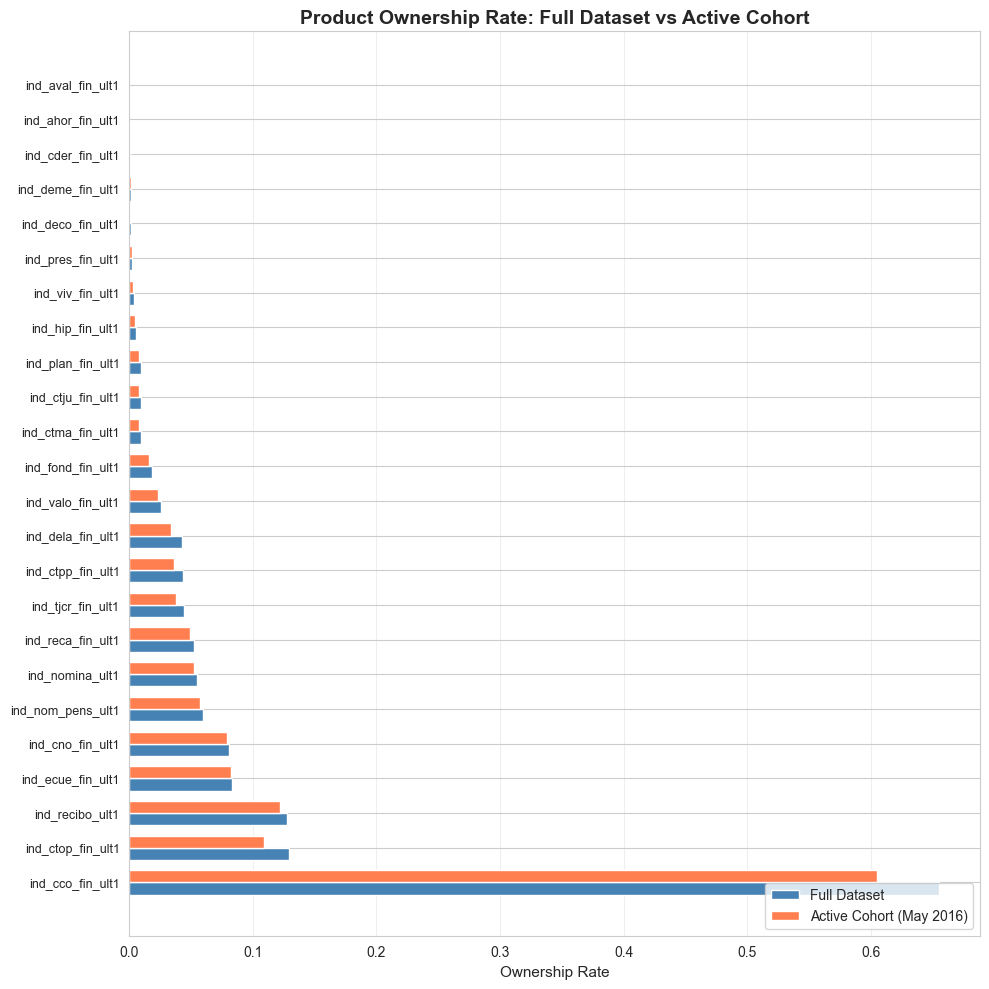

Plot 3 complete: Product ownership comparison
  Max difference: 0.051
  Mean absolute difference: 0.005


In [ ]:
# Create a horizontal bar plot comparing the ownership rates of each product in the full dataset vs the active cohort (May 2016).
PRODUCT_COLS = ['ind_ahor_fin_ult1', 'ind_aval_fin_ult1', 'ind_cco_fin_ult1', 'ind_cder_fin_ult1', 'ind_cno_fin_ult1', 'ind_ctju_fin_ult1', 'ind_ctma_fin_ult1', 'ind_ctop_fin_ult1', 'ind_ctpp_fin_ult1', 'ind_deco_fin_ult1', 'ind_deme_fin_ult1', 'ind_dela_fin_ult1', 'ind_ecue_fin_ult1', 'ind_fond_fin_ult1', 'ind_hip_fin_ult1', 'ind_plan_fin_ult1', 'ind_pres_fin_ult1', 'ind_reca_fin_ult1', 'ind_tjcr_fin_ult1', 'ind_valo_fin_ult1', 'ind_viv_fin_ult1', 'ind_nomina_ult1', 'ind_nom_pens_ult1', 'ind_recibo_ult1']

# Load the full dataset again to calculate overall product ownership rates
df_full = pd.read_parquet(str(PARQUET_PATH), engine='pyarrow')

# Calculate mean ownership rates for each product in the full dataset and the May 2016 cohort
full_rates = df_full[PRODUCT_COLS].mean().sort_values(ascending=False)
cohort_may_rates = df_may[PRODUCT_COLS].mean().reindex(full_rates.index)

# Create a horizontal bar plot comparing the ownership rates of each product in the full dataset vs the active cohort (May 2016)
fig, ax = plt.subplots(figsize=(10, 10))
y_pos = range(len(full_rates))
bar_height = 0.35

# Plot full dataset rates and cohort rates side by side
bars1 = ax.barh([p - bar_height/2 for p in y_pos], full_rates.values, bar_height, label='Full Dataset', color='steelblue')
bars2 = ax.barh([p + bar_height/2 for p in y_pos], cohort_may_rates.values, bar_height, label='Active Cohort (May 2016)', color='coral')
# Set y-ticks to be the product names
ax.set_yticks(y_pos)
ax.set_yticklabels(full_rates.index, fontsize=9)
# Set x-label and title for the plot
ax.set_xlabel('Ownership Rate', fontsize=11)
ax.set_title('Product Ownership Rate: Full Dataset vs Active Cohort', fontsize=14, fontweight='bold')
# Add a legend
ax.legend(loc='lower right')
ax.grid(axis='x', alpha=0.3)

# Adjust layout and display the plot
plt.tight_layout()
plt.show()

# Print comparison information
print('Plot 3 complete: Product ownership comparison')
print(f'  Max difference: {(full_rates - cohort_may_rates).abs().max():.3f}')
print(f'  Mean absolute difference: {(full_rates - cohort_may_rates).abs().mean():.3f}')

## Visual Summary

The 3 plots confirm:
1. Cohort balanced across 3 months
2. Customer segments well represented
3. Cohort representative of full dataset

Validations passed. Ready for Stage 3: Target Engineering.

In [ ]:
# Final summary message
print('\n' + '='*60)
print('Stage 2 Visualisations Complete!')
print('Cohort is validated and representative')
print('Proceeding to Stage 3: Target Engineering')
print('='*60)


Stage 2 Visualisations Complete!
Cohort is validated and representative
Proceeding to Stage 3: Target Engineering
